### **1. 라이브러리 호출**

In [1]:
import numpy as np
import pandas as pd
from IPython.display import display
from pprint import pprint

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
import platform


warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
np.random.seed(42)

# 데이터프레임 출력제한 해제
pd.set_option('display.max_rows', None)      # 행 제한 해제
pd.set_option('display.max_columns', None)   # 열 제한 해제
pd.set_option('display.max_colwidth', None)  # 셀 내용 제한 해제

### **2. 데이터 전처리**

In [2]:
# 데이터 확인

df_shorts = pd.read_csv("../../data/results/preprocessed/it_longform_df.csv", encoding='utf-8')

print(df_shorts.columns.tolist())
print('='*60)
print(df_shorts.info())

['video_id', 'title', 'channel_id', 'channel_title', 'description', 'upload_date', 'tags', 'view_count', 'like_count', 'comment_count', 'duration', 'definition', 'license', 'embeddable', 'has_paid_product_placement', 'thumbnail', 'caption', 'final_url', 'instream_type', 'channel_handle', 'channel_tier', 'subscriber_count', 'domain', 'description_missing_flag', 'tags_missing_flag', 'er', 'ler', 'cer', 'wei', 'description_length', 'category_name', 'upload_year', 'upload_month', 'upload_dayofweek', 'upload_hour', 'tags_count', 'upload_quarter', 'upload_ym_quarter', 'upload_ymd']
<class 'pandas.DataFrame'>
RangeIndex: 5358 entries, 0 to 5357
Data columns (total 39 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   video_id                    5358 non-null   str    
 1   title                       5358 non-null   str    
 2   channel_id                  5358 non-null   str    
 3   channel_title               535

In [3]:
# 데이터 타입 변환
df_shorts['upload_date'] = pd.to_datetime(df_shorts['upload_date']).dt.tz_localize(None)

# 확인
print(df_shorts['upload_date'].dtype) # datetime64[us]
print(df_shorts['upload_date'].head(1)) # 2026-04-24 09:00:31

datetime64[us]
0   2026-04-23 10:02:23
Name: upload_date, dtype: datetime64[us]


### **3. 파생변수 제작 및 데이터 필터링**

In [4]:
# 수집 마지막 날짜를 기준점으로 설정 (경과 일 수 계산 기준)
REFERENCE_DATE = pd.Timestamp("2026-04-27")

# 기준일 - 업로드일 = 영상업로드 후 경과일
df_shorts['elapsed_days'] = (REFERENCE_DATE - df_shorts['upload_date']).dt.days

# 업로드 당일 수집된 영상은 경과일이 0이 되어 RR 계산 시 분모가 0이 됨 -> NaN 처리
df_shorts['elapsed_days'] = df_shorts['elapsed_days'].replace(0, float('nan'))

In [5]:
# 분석 대상 영상 필터링-1 (2021.10.13 ~ 2026.03.27)
ANALYSIS_START = pd.Timestamp("2021-10-13")
ANALYSIS_END = pd.Timestamp("2026-03-27")

df_target = df_shorts[
    (df_shorts['upload_date'] >= ANALYSIS_START)&
    (df_shorts['upload_date'] <= ANALYSIS_END)
].copy()

print(df_target.info())

<class 'pandas.DataFrame'>
Index: 4868 entries, 6 to 5357
Data columns (total 40 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   video_id                    4868 non-null   str           
 1   title                       4868 non-null   str           
 2   channel_id                  4868 non-null   str           
 3   channel_title               4868 non-null   str           
 4   description                 4868 non-null   str           
 5   upload_date                 4868 non-null   datetime64[us]
 6   tags                        4868 non-null   str           
 7   view_count                  4868 non-null   int64         
 8   like_count                  4868 non-null   float64       
 9   comment_count               4868 non-null   float64       
 10  duration                    4868 non-null   float64       
 11  definition                  4868 non-null   str           
 12  license 

In [6]:
# 분석 대상 영상 필터링-2 (조회수 하위 5% 영상 제거)
view_cnt_5pct = df_target['view_count'].quantile(0.05)

df_target_main = df_target[df_target['view_count']>view_cnt_5pct].copy()

print(f"하위 5% 영상의 조회수: {view_cnt_5pct}")
print('='*60)
print(df_target_main.info())

하위 5% 영상의 조회수: 141.0
<class 'pandas.DataFrame'>
Index: 4621 entries, 6 to 5357
Data columns (total 40 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   video_id                    4621 non-null   str           
 1   title                       4621 non-null   str           
 2   channel_id                  4621 non-null   str           
 3   channel_title               4621 non-null   str           
 4   description                 4621 non-null   str           
 5   upload_date                 4621 non-null   datetime64[us]
 6   tags                        4621 non-null   str           
 7   view_count                  4621 non-null   int64         
 8   like_count                  4621 non-null   float64       
 9   comment_count               4621 non-null   float64       
 10  duration                    4621 non-null   float64       
 11  definition                  4621 non-null   str    

In [7]:
# RR 계산
# (총 조회수/업로드 후 경과일수)/구독자수

df_target_main['RR'] = (df_target_main['view_count']/df_target_main['elapsed_days']) / df_target_main['subscriber_count']

In [8]:
channel_cnt = df_target_main['channel_id'].value_counts()

print(f"\n채널 수: {df_target_main['channel_id'].nunique()}")
print(f"\n[채널별 영상 수]\n{channel_cnt}")


채널 수: 34

[채널별 영상 수]
channel_id
UCwR9k7QggFEfeHkvTR31JcA    1407
UCp3BSINVC7Ggj4kChEUiy7Q     467
UCVaIGU8ch9zG42j-rAG6VoA     411
UCZHb3OEEJ0WkizEH9ErlgvA     297
UCqqoiebjYnMqfhx-4f1awKg     276
UC2wPiIf2xSXGTJNqo8UOY9g     213
UCjyYouHWnID_L4QaQ6U4voQ     200
UCBjvBJgIp3NGkrTBEfWBUVw     180
UCQNv-1JeNQ9I_xKlLD6QmhA     165
UCgtGQjfrfO_uAnH6JcB1MTA     163
UCsY3aR2FYK4SbM2tBLksWtQ     102
UCqz8F0bdoDiyzgdYPZAdA-Q      97
UCpCNaKju3d8YNq4trfwcJrA      95
UCRBtxwx23bzxyr5R9vFRYhw      85
UCmWvEmIve2QHxqgWXAblahA      59
UCjpcrwZnzmLdSrxVcdZd0cQ      59
UC_7nyGIBuYk6HBBBftbn3kg      53
UCsc2G8g0k-H15yYuQQv7AYQ      45
UCSvOg4rSu395lPz6uMqBekw      44
UCz-j1tzeMCqvOX0YNkOXIAw      35
UCm0COQdmdRLN23D4gUK3FAA      33
UCsfezAG3HiKjf7OrYTdNZxg      31
UCdc_SRhKUlH3grljQXA0skw      25
UCuDsOOa9CtAWwv7_rmuL14g      24
UCsdkfl1-goECoNJUp4aMJ7Q      17
UCNucE-FsBf3RITeGbsE3RKw      11
UCn41TnmQX9Ccswo89wDBiyg       7
UCDT2efYTZ8y516QjrfsDQSA       7
UCrdvKtWTpBfOx9kFCQ6aK3A       4
UCNUz9CIAl

In [9]:
print(f"영상 10개 미만 채널 수: {(channel_cnt < 10).sum()}개")
print(f"영상 10개 이상 채널 수: {(channel_cnt >= 10).sum()}개")
print(f"\n[영상 수 통계]\n{channel_cnt.describe()}")

영상 10개 미만 채널 수: 8개
영상 10개 이상 채널 수: 26개

[영상 수 통계]
count      34.000000
mean      135.911765
std       254.020802
min         1.000000
25%        12.500000
50%        49.000000
75%       164.500000
max      1407.000000
Name: count, dtype: float64


In [10]:
# 구간별 채널 수 및 채널 비율 확인
total_channels = len(channel_cnt)

for threshold in [5, 10, 15, 20]:
    below_channels = (channel_cnt < threshold).sum()
    above_channels = (channel_cnt >= threshold).sum()
    below_pct = below_channels / total_channels * 100

    print(f"기준 {threshold:2d}개 → "
          f"기준 미만: {below_channels}개 채널 ({below_pct:.1f}%) / "
          f"기준 이상: {above_channels}개 채널 ({100 - below_pct:.1f}%)")

기준  5개 → 기준 미만: 6개 채널 (17.6%) / 기준 이상: 28개 채널 (82.4%)
기준 10개 → 기준 미만: 8개 채널 (23.5%) / 기준 이상: 26개 채널 (76.5%)
기준 15개 → 기준 미만: 9개 채널 (26.5%) / 기준 이상: 25개 채널 (73.5%)
기준 20개 → 기준 미만: 10개 채널 (29.4%) / 기준 이상: 24개 채널 (70.6%)


In [11]:
# 컬럼명 변경
df_target_main = df_target_main.rename(columns={
    # 기본 정보
    'channel_title'    : '채널명',
    'upload_date'      : '업로드일시',
    'duration'         : '영상길이(초)',

    # 수치 지표
    'view_count'       : '조회수',
    'like_count'       : '좋아요수',
    'comment_count'    : '댓글수',
    'subscriber_count' : '구독자수',

    # 파생 지표
    'elapsed_days'     : '경과일수',
    'RR'               : '도달률(RR)',       # Reach Rate
    'er'               : '참여율(ER)',       # Engagement Rate
    'ler'              : '조회수 대비 좋아요율',     # Like Engagement Rate
    'cer'              : '조회수 대비 댓글률',       # Comment Engagement Rate
})

# 결과 확인
pprint(df_target_main.columns.tolist())

['video_id',
 'title',
 'channel_id',
 '채널명',
 'description',
 '업로드일시',
 'tags',
 '조회수',
 '좋아요수',
 '댓글수',
 '영상길이(초)',
 'definition',
 'license',
 'embeddable',
 'has_paid_product_placement',
 'thumbnail',
 'caption',
 'final_url',
 'instream_type',
 'channel_handle',
 'channel_tier',
 '구독자수',
 'domain',
 'description_missing_flag',
 'tags_missing_flag',
 '참여율(ER)',
 '조회수 대비 좋아요율',
 '조회수 대비 댓글률',
 'wei',
 'description_length',
 'category_name',
 'upload_year',
 'upload_month',
 'upload_dayofweek',
 'upload_hour',
 'tags_count',
 'upload_quarter',
 'upload_ym_quarter',
 'upload_ymd',
 '경과일수',
 '도달률(RR)']


In [12]:
# 일평균 조회수 = 조회수 / 경과일수
df_target_main['일평균 조회수'] = df_target_main['조회수'] / df_target_main['경과일수']

# 결과 확인
print(df_target_main['일평균 조회수'].describe())

count     4621.000000
mean       133.471422
std       1277.756546
min          0.091843
25%          0.576471
50%          1.417978
75%          5.645489
max      39814.401235
Name: 일평균 조회수, dtype: float64


---
### 4. 지표 1
- ER과 RR을 활용하는 지표
- 가중치를 구하는 방법 (후보)
    - CV 기반 ✅ 채택
        - 두 지표가 독립적이라는 가정 하에 CV값이 더 큰 값이 영상간의 차이를 변별하기 좋을 것이기 때문에 더 높은 가중치 부여
    - PCA 기반 ❌ 불가
        - RR과 ER을 PCA에 넣었을 때, 전체 분산을 가장 잘 설명하는 첫번째 주성분(PC1)에서 각 변수의 기여도(loading)를
        w1, w2로 사용하는 방법
        - 변수가 2개일 때 표준화된 데이터에서 PC1의 loading² + PC2의 loading²이
          항상 동일하게 나와 수학적으로 가중치 차별화가 불가능

In [13]:
# -------------------------------------------------------
# CV(변동계수) 기반 채널별 가중치(w1, w2) 산출
# RR과 ER 중 채널 내 영상 간 변별력이 높은 지표에 높은 가중치 부여
# -------------------------------------------------------
channel_weights = {} # 채널별 가중치

for channel_id, group in df_target_main.groupby('channel_id'):

    # 영상 10개 미만 채널은 CV 계산이 불안정하므로 균등 가중치 적용 (영상 개수는 협의 필요)
    if len(group) < 10:
        channel_weights[channel_id] = {'w1': 0.5, 'w2': 0.5}
        continue

    # CV = 표준편차 / 평균
    # CV가 클수록 영상 간 차이를 더 잘 변별하는 지표
    cv_rr = group['도달률(RR)'].std() / group['도달률(RR)'].mean()
    cv_er = group['참여율(ER)'].std() / group['참여율(ER)'].mean()
    cv_sum = cv_rr + cv_er

    # cv_sum이 0인 경우 (모든 영상의 RR, ER이 동일) 균등 가중치 적용
    if cv_sum == 0:
        channel_weights[channel_id] = {'w1': 0.5, 'w2': 0.5}
        continue

    channel_weights[channel_id] = {
        'w1': cv_rr / cv_sum,  # RR의 변별력 비율
        'w2': cv_er / cv_sum   # ER의 변별력 비율
    }

# 딕셔너리 → DataFrame으로 변환 (행: channel_id, 열: w1, w2)
channel_weights_df = pd.DataFrame(channel_weights).T
channel_weights_df.index.name = 'channel_id'

# 확인
print(f"[채널별 가중치]")
print(channel_weights_df)
print(f"\n[가중치 통계]")
print(channel_weights_df.describe())
print(f"\n균등 가중치 적용 채널 수: {(channel_cnt < 10).sum()}개")

[채널별 가중치]
                                w1        w2
channel_id                                  
UC2wPiIf2xSXGTJNqo8UOY9g  0.679236  0.320764
UC8RTcqBjB7I9lD_4l8cmwHg  0.500000  0.500000
UCBjvBJgIp3NGkrTBEfWBUVw  0.740886  0.259114
UCDT2efYTZ8y516QjrfsDQSA  0.500000  0.500000
UCMaDyFlagYlsolLLfWHu7Dw  0.500000  0.500000
UCNUz9CIAlWDtaLWvFWzgsww  0.500000  0.500000
UCNucE-FsBf3RITeGbsE3RKw  0.481787  0.518213
UCQNv-1JeNQ9I_xKlLD6QmhA  0.642091  0.357909
UCRBtxwx23bzxyr5R9vFRYhw  0.772463  0.227537
UCSvOg4rSu395lPz6uMqBekw  0.699464  0.300536
UCVaIGU8ch9zG42j-rAG6VoA  0.889222  0.110778
UCZHb3OEEJ0WkizEH9ErlgvA  0.963763  0.036237
UC_7nyGIBuYk6HBBBftbn3kg  0.926573  0.073427
UCcFA2TC568rGp94OqMq3Nig  0.500000  0.500000
UCdc_SRhKUlH3grljQXA0skw  0.878433  0.121567
UCgtGQjfrfO_uAnH6JcB1MTA  0.767139  0.232861
UCjpcrwZnzmLdSrxVcdZd0cQ  0.651408  0.348592
UCjyYouHWnID_L4QaQ6U4voQ  0.847336  0.152664
UCm0COQdmdRLN23D4gUK3FAA  0.646884  0.353116
UCmWvEmIve2QHxqgWXAblahA  0.321169  0.678831


In [14]:
# 가중치의 평균값 적용
# 다양한 채널의 특성을 반영했으면서도 모든 영상에 동일한 기준을 적용하면 다른 채널의 영상끼리도 비교하기 좋을 것 같음
w1 = channel_weights_df['w1'].mean()
w2 = channel_weights_df['w2'].mean()

print(f"w1 (RR 가중치): {w1:.4f}") # w1 (RR 가중치): 0.6688
print(f"w2 (ER 가중치): {w2:.4f}") # w2 (ER 가중치): 0.3312

w1 (RR 가중치): 0.6462
w2 (ER 가중치): 0.3538


In [15]:
# 전체 영상을 기준으로 백분위 계산
# rank(pct=True): 0~1 사이 백분위로 변환
df_target_main['RR_백분위'] = df_target_main['도달률(RR)'].rank(pct=True)
df_target_main['ER_백분위'] = df_target_main['참여율(ER)'].rank(pct=True)

# score1 = w1 * RR백분위 + w2 * ER백분위
# 0~1 사이 값, 높을수록 성과가 좋은 영상
df_target_main['score1'] = (
    w1 * df_target_main['RR_백분위'] + w2 * df_target_main['ER_백분위']
)

# 결과 확인
print(f"[score1 통계]")
print(df_target_main['score1'].describe())
print(f"\n[RR_백분위 통계]")
print(df_target_main['RR_백분위'].describe())
print(f"\n[ER_백분위 통계]")
print(df_target_main['ER_백분위'].describe())

[score1 통계]
count    4621.000000
mean        0.500108
std         0.198858
min         0.013690
25%         0.340635
50%         0.512680
75%         0.649578
max         0.989226
Name: score1, dtype: float64

[RR_백분위 통계]
count    4621.000000
mean        0.500108
std         0.288706
min         0.000216
25%         0.250162
50%         0.500108
75%         0.750054
max         1.000000
Name: RR_백분위, dtype: float64

[ER_백분위 통계]
count    4621.000000
mean        0.500108
std         0.288706
min         0.008656
25%         0.250162
50%         0.500108
75%         0.750054
max         1.000000
Name: ER_백분위, dtype: float64


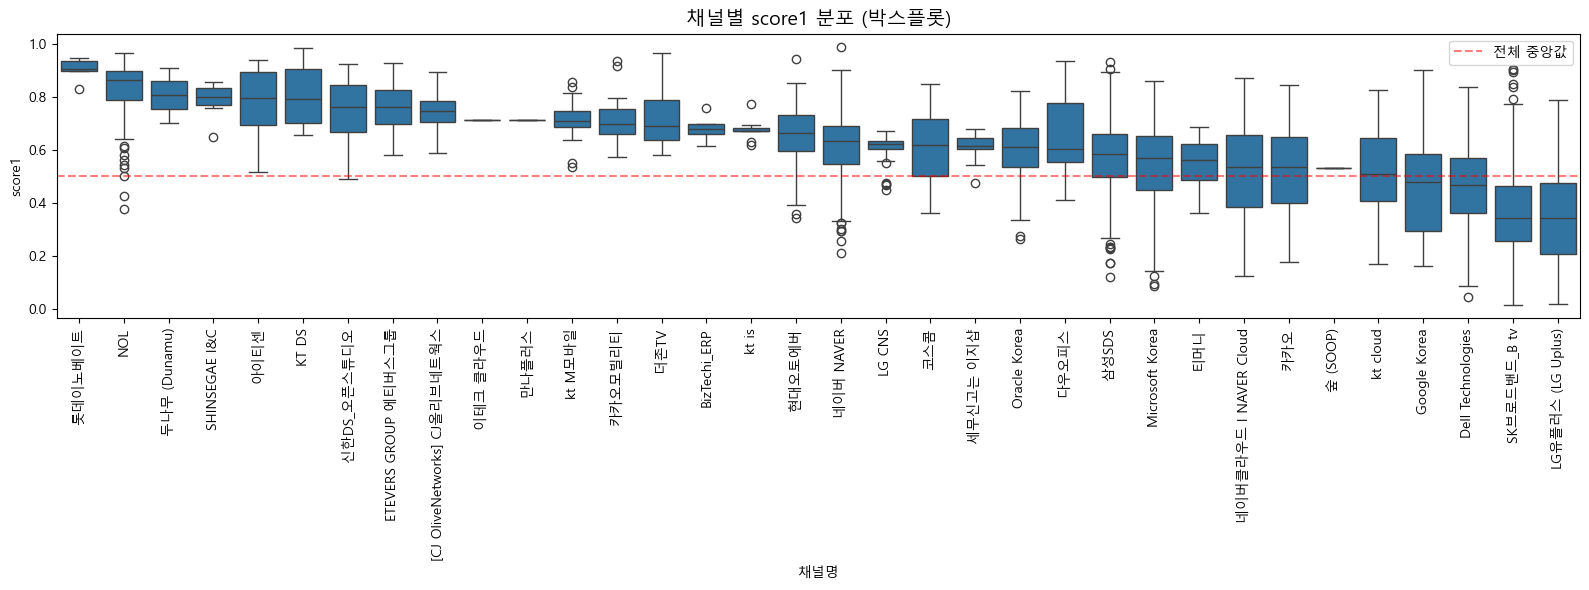

In [16]:
# 채널별 score1 분포 비교 시각화 (박스플롯)
fig, ax = plt.subplots(figsize=(16, 6))

# 채널별 score1 중앙값 기준으로 정렬
channel_order = (
    df_target_main.groupby('채널명')['score1']
    .median()
    .sort_values(ascending=False)
    .index
)

# 박스플롯 (이상치 포함 전체 분포)
sns.boxplot(
    data=df_target_main,
    x='채널명', y='score1',
    order=channel_order,
    ax=ax
)
ax.set_title('채널별 score1 분포 (박스플롯)', fontsize=14)
ax.set_xlabel('채널명')
ax.set_ylabel('score1')
ax.tick_params(axis='x', rotation=90)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='전체 중앙값')
ax.legend()

plt.tight_layout()
plt.show()

---
### **5. 지표 2**
- 일평균 조회수, 좋아요율(ler), 댓글률(cer)을 활용하는 지표
- 채널 생성 후 경과 시간에 관계없이 특정 영상이 업로드되기 직전 3개월 동안
  업로드된 영상들의 평균값을 기준으로 해당 영상의 상대적 성과를 측정
- 직전 3개월 참조 영상에서 해당 영상 자신은 제외
- 참조 영상이 0개인 경우 (채널 초기 영상) → 지표 2 계산 제외

- 3가지 성과 지표
    - 조회수 성과 = 해당 영상의 일평균 조회수 / 직전 3개월 영상들의 평균 일평균 조회수
    - 좋아요 성과 = 해당 영상의 좋아요율(ler) / 직전 3개월 영상들의 평균 좋아요율
    - 댓글 성과  = 해당 영상의 댓글률(cer) / 직전 3개월 영상들의 평균 댓글률

- 가중치를 구하는 방법 (후보)
    - CV 기반
        - 3가지 성과 지표 각각의 CV를 구해서 변별력이 높은 지표에 높은 가중치 부여
    - PCA 기반
        - 변수가 3개이므로 PC1의 loading을 가중치로 사용 가능
        - CV 기반과 비교 후 선택

In [17]:
# 같은 채널에서 같은 날 업로드된 영상 확인
# 직전 3개월 참조 그룹 계산 시 동일 날짜 처리 방침 결정을 위해
same_day = df_target_main.groupby(['channel_id', 'upload_ymd']).size()
same_day = same_day[same_day > 1]

print(f"같은 날 2개 이상 업로드된 경우: {len(same_day)}건") # 908건

같은 날 2개 이상 업로드된 경우: 834건


In [18]:
# 채널별 같은 날 2개 이상 업로드된 건수 확인
same_day_by_channel = (
    df_target_main.groupby(['channel_id', 'upload_ymd']).size()
    .reset_index(name='daily_count')
)

# 하루에 2개 이상 업로드된 날만 필터링
same_day_by_channel = same_day_by_channel[same_day_by_channel['daily_count'] > 1]

# 채널별 집계
same_day_summary = (
    same_day_by_channel.groupby('channel_id')
    .agg(
        중복업로드_날짜수=('upload_ymd', 'count'),
        중복업로드_최대=('daily_count', 'max')
    )
    .reset_index()
)

# 채널명 붙이기
same_day_summary = same_day_summary.merge(
    df_target_main[['channel_id', '채널명']].drop_duplicates(),
    on='channel_id'
)

# 결과 데이터 프레임
result = (
    same_day_summary[['채널명', '중복업로드_날짜수', '중복업로드_최대']]
    .sort_values('중복업로드_날짜수', ascending=False)
    .reset_index(drop=True)
)

print(f"같은 날 2개 이상 업로드한 채널 수: {len(same_day_summary)}개")
print(f"\n[채널별 중복 업로드 현황]")
display(result)

같은 날 2개 이상 업로드한 채널 수: 29개

[채널별 중복 업로드 현황]


,채널명,중복업로드_날짜수,중복업로드_최대
0,SK브로드밴드_B tv,431,15
1,LG유플러스 (LG Uplus),84,17
2,Dell Technologies,61,7
3,삼성SDS,45,45
4,Microsoft Korea,34,20
5,네이버클라우드 l NAVER Cloud,31,13
6,네이버 NAVER,30,54
7,Oracle Korea,20,7
8,카카오,19,21
9,kt cloud,19,30


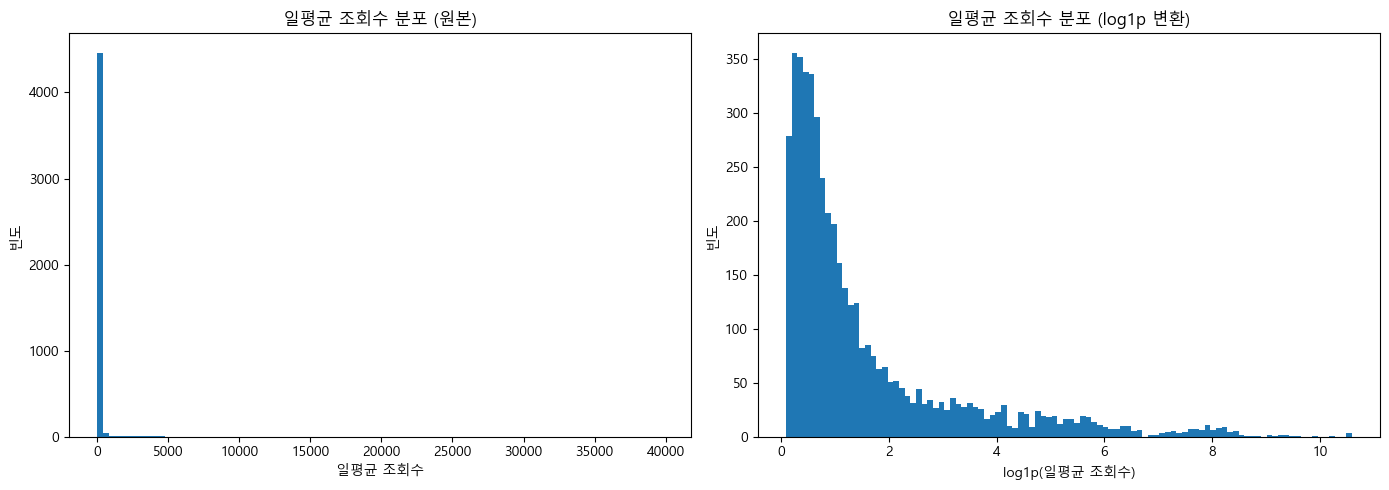

원본 왜도: 22.1200
로그변환 후 왜도: 2.0315


In [19]:
# 일평균 조회수 성과에서 로그변환이 필요한지 판단
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 원본 분포
axes[0].hist(df_target_main['일평균 조회수'], bins=100, edgecolor='none')
axes[0].set_title('일평균 조회수 분포 (원본)')
axes[0].set_xlabel('일평균 조회수')
axes[0].set_ylabel('빈도')

# 2. 로그변환 후 분포
axes[1].hist(np.log1p(df_target_main['일평균 조회수']), bins=100, edgecolor='none')
axes[1].set_title('일평균 조회수 분포 (log1p 변환)')
axes[1].set_xlabel('log1p(일평균 조회수)')
axes[1].set_ylabel('빈도')

plt.tight_layout()
plt.show()

# 왜도(skewness) 확인
from scipy.stats import skew
print(f"원본 왜도: {skew(df_target_main['일평균 조회수']):.4f}")
print(f"로그변환 후 왜도: {skew(np.log1p(df_target_main['일평균 조회수'])):.4f}")

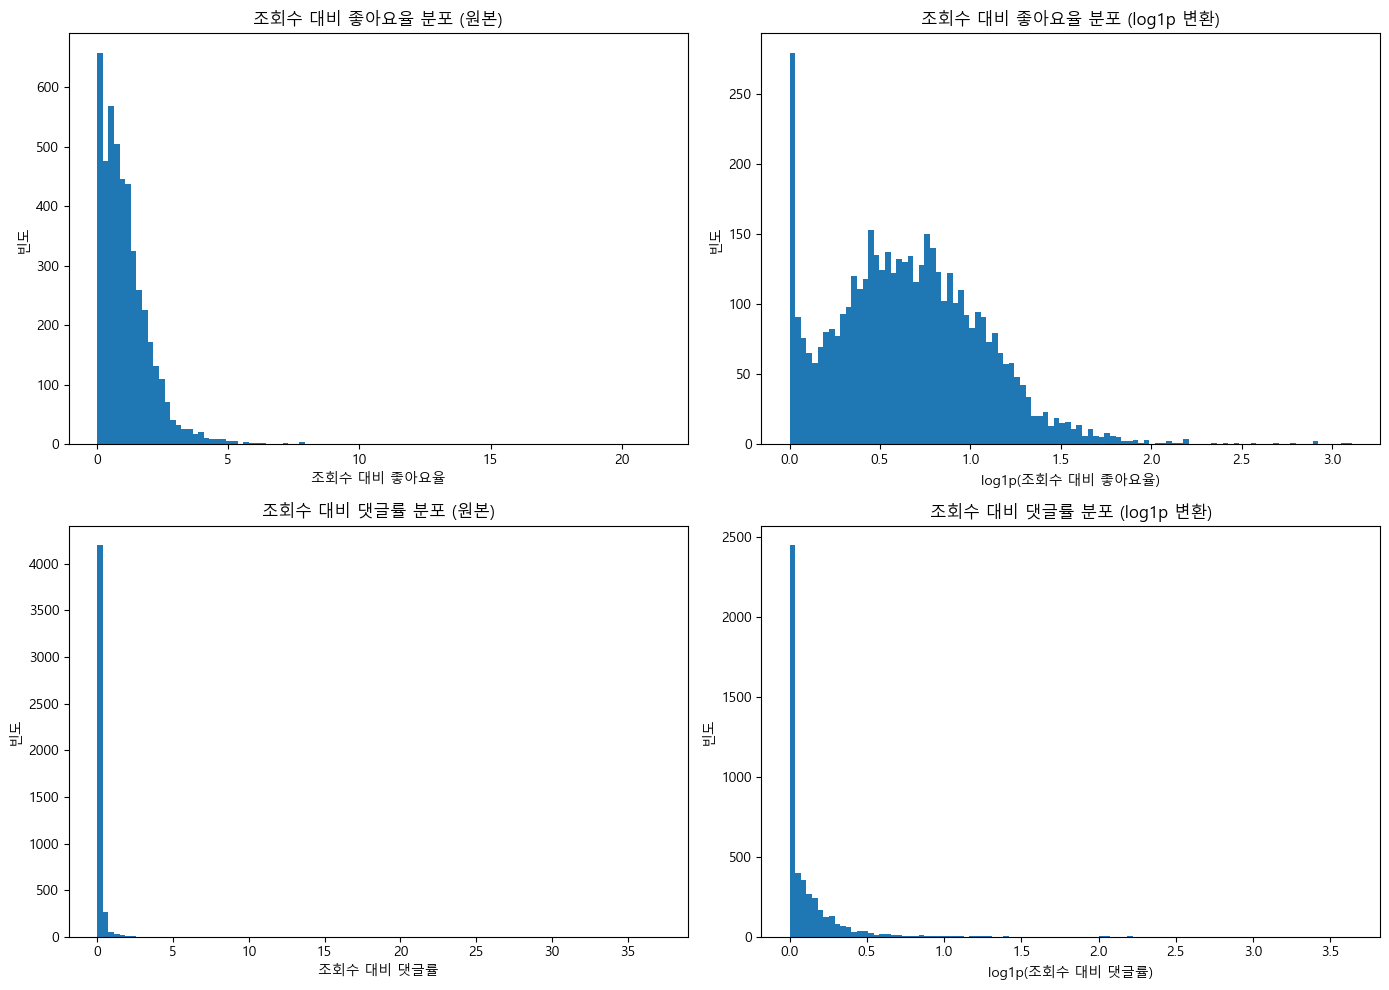

[조회수 대비 좋아요율]
  원본 왜도     : 5.4444
  로그변환 후 왜도: 0.6043
[조회수 대비 댓글률]
  원본 왜도     : 20.8169
  로그변환 후 왜도: 6.2896


In [20]:
# 좋아요율, 댓글률의 데이터 분포 확인
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(['조회수 대비 좋아요율', '조회수 대비 댓글률']):
    # 원본
    axes[i][0].hist(df_target_main[col], bins=100, edgecolor='none')
    axes[i][0].set_title(f'{col} 분포 (원본)')
    axes[i][0].set_xlabel(col)
    axes[i][0].set_ylabel('빈도')

    # 로그변환
    axes[i][1].hist(np.log1p(df_target_main[col]), bins=100, edgecolor='none')
    axes[i][1].set_title(f'{col} 분포 (log1p 변환)')
    axes[i][1].set_xlabel(f'log1p({col})')
    axes[i][1].set_ylabel('빈도')

plt.tight_layout()
plt.show()

# 왜도 확인
for col in ['조회수 대비 좋아요율', '조회수 대비 댓글률']:
    print(f"[{col}]")
    print(f"  원본 왜도     : {skew(df_target_main[col]):.4f}")
    print(f"  로그변환 후 왜도: {skew(np.log1p(df_target_main[col])):.4f}")

In [21]:
print(f"댓글률 = 0인 영상 수: {(df_target_main['조회수 대비 댓글률'] == 0).sum()}개")
print(f"전체 대비 비율: {(df_target_main['조회수 대비 댓글률'] == 0).mean()*100:.1f}%")

print(f"\n좋아요율 = 0인 영상 수: {(df_target_main['조회수 대비 좋아요율'] == 0).sum()}개")
print(f"전체 대비 비율: {(df_target_main['조회수 대비 좋아요율'] == 0).mean()*100:.1f}%")

댓글률 = 0인 영상 수: 1850개
전체 대비 비율: 40.0%

좋아요율 = 0인 영상 수: 104개
전체 대비 비율: 2.3%


---
- 기본적인 데이터 분포 확인 결과
    - 공통: 댓글성과는 왜도가 높고 0값이 30.9%로 많으므로 어떤 방법이든 상대적으로 낮은 가중치 부여하는 것이 좋을 것 같음

In [22]:
# -------------------------------------------------------
# 지표2 - 영상별 직전 3개월 업로드된 영상을 기반으로 조회수/댓글/좋아요 성과 계산
# 일평균 조회수, 좋아요율, 댓글률 모두 log1p 변환 적용 
# -> 원본 데이터로 계산 시, 왜도가 너무 높아 극단값 영향을 제거하기 위해
# -------------------------------------------------------

# 참조용 데이터프레임 생성
# 분석 대상 마지막 날짜(2026-03-27) 이후 영상은 참조 그룹에서 제외
ANALYSIS_END = pd.Timestamp("2026-03-27")
df_ref = df_shorts[df_shorts['upload_date'] <= ANALYSIS_END].copy()

results = []  # 영상별 지표 2 결과 저장

for idx, row in df_target_main.iterrows():

    channel_id   = row['channel_id']
    upload_date  = row['업로드일시']
    window_start = upload_date - pd.DateOffset(months=3)

    # 직전 3개월 참조 그룹 추출
    # 원본 데이터(df_ref)에서 탐색 → 버퍼 기간(2021-07-13~2021-10-12) 영상 포함
    # 같은 채널, 업로드 시각 기준 이전 영상만 포함 (해당 영상 자신 제외)
    ref = df_ref[
        (df_ref['channel_id'] == channel_id) &
        (df_ref['upload_date'] >= window_start) &
        (df_ref['upload_date'] < upload_date)
    ]

    # 참조 영상이 없으면 지표 2 계산 불가 → NaN 처리
    if len(ref) == 0:
        results.append({'video_id'  : row['video_id'],
                        '조회수성과': None,
                        '좋아요성과': None,
                        '댓글성과'  : None})
        continue

    # 참조 그룹 평균값 계산 (log1p 변환 후 평균)
    # 분모: 직전 3개월 영상들의 log1p 변환 후 평균값
    ref_avg_daily_view = np.log1p(ref['view_count'] / ref['elapsed_days']).mean()  # 일평균 조회수 직접 계산
    ref_avg_ler = np.log1p(ref['ler']).mean()
    ref_avg_cer = np.log1p(ref['cer']).mean()

    # 3가지 성과 지표 계산 (분모가 0이면 NaN 처리)
    # 조회수 성과 = log1p(해당 영상 일평균 조회수)(분자) / log1p(참조 그룹 평균 일평균 조회수)(분모)
    view_score = (np.log1p(row['일평균 조회수']) / ref_avg_daily_view
                  if ref_avg_daily_view != 0 else None)

    # 좋아요 성과 = log1p(해당 영상 좋아요율)(분자) / log1p(참조 그룹 평균 좋아요율)(분모)
    like_score = (np.log1p(row['조회수 대비 좋아요율']) / ref_avg_ler
                  if ref_avg_ler != 0 else None)

    # 댓글 성과 = log1p(해당 영상 댓글률)(분자) / log1p(참조 그룹 평균 댓글률)(분모)
    comm_score = (np.log1p(row['조회수 대비 댓글률']) / ref_avg_cer
                  if ref_avg_cer != 0 else None)

    results.append({
        'video_id'  : row['video_id'],
        '조회수성과': view_score,
        '좋아요성과': like_score,
        '댓글성과'  : comm_score
    })

# 결과 DataFrame으로 변환 후 병합
result_df = pd.DataFrame(results)
df_target_main = df_target_main.merge(result_df, on='video_id', how='left')

# 확인
print(f"[지표 2 성과 통계]")
display(df_target_main[['조회수성과', '좋아요성과', '댓글성과']].describe())

[지표 2 성과 통계]


,조회수성과,좋아요성과,댓글성과
count,4531.000000,4528.000000,4349.000000
mean,1.105334,1.054216,1.333204
std,1.013220,0.814562,5.962220
min,0.056534,0.000000,0.000000
25%,0.473804,0.622294,0.000000
50%,0.857497,0.969410,0.364433
75%,1.381930,1.315503,1.406546
max,25.643168,12.577342,346.906131


In [23]:
# 세 가지 성과지표 중 하나라도 NaN인 영상 제거
before = len(df_target_main)

df_target_main2 = df_target_main.dropna(
    subset=['조회수성과', '좋아요성과', '댓글성과']
)

after = len(df_target_main2)

print(f"제거 전 영상 수: {before}") # 6281
print(f"제거 후 영상 수: {after}") # 5964
print(f"제거된 영상 수: {before - after}") # 317

제거 전 영상 수: 4621
제거 후 영상 수: 4349
제거된 영상 수: 272


In [24]:
# df_target_main2 기준 성과지표 통계 확인
print(f"[성과지표 통계]")
display(df_target_main2[['조회수성과', '좋아요성과', '댓글성과']].describe())

# 왜도 확인
for col in ['조회수성과', '좋아요성과', '댓글성과']:
    print(f"{col} 왜도: {skew(df_target_main2[col]):.4f}")

[성과지표 통계]


,조회수성과,좋아요성과,댓글성과
count,4349.000000,4349.000000,4349.000000
mean,1.082420,1.052443,1.333204
std,0.920095,0.804104,5.962220
min,0.056534,0.000000,0.000000
25%,0.466862,0.623469,0.000000
50%,0.841981,0.971428,0.364433
75%,1.367208,1.319228,1.406546
max,11.182260,12.577342,346.906131


조회수성과 왜도: 2.5357
좋아요성과 왜도: 4.5804
댓글성과 왜도: 45.6178


In [25]:
# 성과지표별 상위 1%, 5% 확인
for col in ['조회수성과', '좋아요성과', '댓글성과']:
    pct99 = df_target_main2[col].quantile(0.99)
    pct95 = df_target_main2[col].quantile(0.95)
    print(f"{col} - 상위 1%: {pct99:.4f} / 상위 5%: {pct95:.4f}")

조회수성과 - 상위 1%: 4.5124 / 상위 5%: 2.8900
좋아요성과 - 상위 1%: 3.6623 / 상위 5%: 2.1513
댓글성과 - 상위 1%: 12.2378 / 상위 5%: 5.1267


In [26]:
# -------------------------------------------------------
# 성과지표 이상치 flag 생성 (상위 1%, 5% 기준)
# 클리핑 없이 flag만 남기고
# 가중치 계산은 이상치 제외, score2 계산은 전체 영상에 적용
# -------------------------------------------------------

for col, flag_col_1, flag_col_5 in [
    ('조회수성과', '조회수성과_상위1%', '조회수성과_상위5%'),
    ('좋아요성과', '좋아요성과_상위1%', '좋아요성과_상위5%'),
    ('댓글성과',   '댓글성과_상위1%',   '댓글성과_상위5%')
]:
    pct99 = df_target_main2[col].quantile(0.99)
    pct95 = df_target_main2[col].quantile(0.95)

    # 상위 1% 초과 flag (1: 이상치, 0: 정상)
    df_target_main2[flag_col_1] = (df_target_main2[col] > pct99).astype(int)
    # 상위 5% 초과 flag (1: 이상치, 0: 정상)
    df_target_main2[flag_col_5] = (df_target_main2[col] > pct95).astype(int)

# 결과 확인
print(f"[이상치 flag 현황]")
for col in ['조회수성과', '좋아요성과', '댓글성과']:
    cnt_1 = df_target_main2[f'{col}_상위1%'].sum()
    cnt_5 = df_target_main2[f'{col}_상위5%'].sum()
    print(f"{col} - 상위 1%: {cnt_1}개 / 상위 5%: {cnt_5}개")

[이상치 flag 현황]
조회수성과 - 상위 1%: 44개 / 상위 5%: 218개
좋아요성과 - 상위 1%: 44개 / 상위 5%: 218개
댓글성과 - 상위 1%: 44개 / 상위 5%: 218개


---
### **5-1. 이상치로 분류된 영상을 어떻게 처리해보면 좋을까..**

- 성과지표(조회수성과, 좋아요성과, 댓글성과) 계산 후 상위 1% 영상을 이상치로 정의
- 이상치 영상은 클리핑(상위 1% 기준)으로 처리하되, 이상치 여부를 flag로 기록
    - 조회수성과_이상치, 좋아요성과_이상치, 댓글성과_이상치 (1: 이상치, 0: 정상)

- 이상치 영상을 별도로 가중치 계산하지 않는 이유
    - 이상치 영상 수가 60개(1.0%)로 너무 적어 가중치 계산이 불안정함
    - 채널별로 분산되어 있어 채널당 이상치 영상이 1~2개뿐일 가능성이 높음

- 이상치 영상은 메인 지표 선택 및 가중치 확정 이후 추가 분석 예정
    - 이상치 영상과 일반 영상의 성과 분포 비교
    - 이상치 영상의 공통점 분석 (업로드 요일, 시간대, 카테고리 등)

- 기대하는 인사이트
    - Case 1: 이상치가 고성과 영상에 몰림 → "바이럴 영상이 진짜 성공 영상"
    - Case 2: 이상치가 골고루 분포 → "바이럴이 반드시 성공을 의미하진 않음"
    - Case 3: 이상치가 저성과 영상에도 많음 → "조회수만 터지고 참여율은 낮은 영상 존재"
---

In [27]:
# 상위 1%, 5% 영상을 각각 제외한 경우 왜도 비교
# → 가중치 계산 시 이상치 제외 기준 결정을 위해
for threshold, col_suffix in [(0.99, '상위1%'), (0.95, '상위5%')]:

    # 상위 1% 제외
    if threshold == 0.99:
        df_temp = df_target_main2[
            (df_target_main2['조회수성과_상위1%'] == 0) &
            (df_target_main2['좋아요성과_상위1%'] == 0) &
            (df_target_main2['댓글성과_상위1%'] == 0)
        ]
    # 상위 5% 제외
    else:
        df_temp = df_target_main2[
            (df_target_main2['조회수성과_상위5%'] == 0) &
            (df_target_main2['좋아요성과_상위5%'] == 0) &
            (df_target_main2['댓글성과_상위5%'] == 0)
        ]

    print(f"\n[{col_suffix} 제외 후 왜도] (영상 수: {len(df_temp)}개)")
    print('-' * 40)
    for col in ['조회수성과', '좋아요성과', '댓글성과']:
        print(f"  {col}: {skew(df_temp[col]):.4f}")
    print('-' * 40)


[상위1% 제외 후 왜도] (영상 수: 4226개)
----------------------------------------
  조회수성과: 1.5238
  좋아요성과: 0.7886
  댓글성과: 2.8171
----------------------------------------

[상위5% 제외 후 왜도] (영상 수: 3757개)
----------------------------------------
  조회수성과: 0.9703
  좋아요성과: 0.0495
  댓글성과: 1.6757
----------------------------------------


In [28]:
# -------------------------------------------------------
# 가중치 계산용 데이터프레임 생성
# 세 가지 성과지표 중 하나라도 상위 5% 이상치인 영상 제외
# score2 계산은 이상치 포함 전체 영상(df_target_main2)에 적용
# -------------------------------------------------------

df_weight_calc = df_target_main2[
    (df_target_main2['조회수성과_상위5%'] == 0) &
    (df_target_main2['좋아요성과_상위5%'] == 0) &
    (df_target_main2['댓글성과_상위5%'] == 0)
].copy()

print(f"전체 영상 수: {len(df_target_main2)}")
print(f"가중치 계산용 영상 수: {len(df_weight_calc)}")
print(f"제외된 영상 수: {len(df_target_main2) - len(df_weight_calc)}")
print(f"\n[가중치 계산용 데이터프레임의 왜도]")
for col in ['조회수성과', '좋아요성과', '댓글성과']:
    print(f"  {col}: {skew(df_weight_calc[col]):.4f}")

전체 영상 수: 4349
가중치 계산용 영상 수: 3757
제외된 영상 수: 592

[가중치 계산용 데이터프레임의 왜도]
  조회수성과: 0.9703
  좋아요성과: 0.0495
  댓글성과: 1.6757


In [29]:
# -------------------------------------------------------
# 지표 2 - CV 기반 가중치(a, b, c) 산출
# 변별력이 높은 성과지표에 높은 가중치 부여
# -------------------------------------------------------

# CV = 표준편차 / 평균
cv_view = df_weight_calc['조회수성과'].std() / df_weight_calc['조회수성과'].mean()
cv_like = df_weight_calc['좋아요성과'].std() / df_weight_calc['좋아요성과'].mean()
cv_comm = df_weight_calc['댓글성과'].std()   / df_weight_calc['댓글성과'].mean()
cv_sum  = cv_view + cv_like + cv_comm

a_cv = cv_view / cv_sum  # 조회수성과 가중치
b_cv = cv_like / cv_sum  # 좋아요성과 가중치
c_cv = cv_comm / cv_sum  # 댓글성과 가중치

print(f"[CV 기반 가중치]")
print(f"a (조회수성과): {a_cv:.4f}") # 0.1593
print(f"b (좋아요성과): {b_cv:.4f}") # 0.2459
print(f"c (댓글성과)  : {c_cv:.4f}") # 0.5948
print(f"합계: {a_cv + b_cv + c_cv:.4f}")

# 댓글의 왜도가 가장 컸는데, 
# 댓글성과의 분포를 보면 25%의 임계값도 0으로 댓글이 없는 경우가 많아서 변동성이 커진 것으로 보는 것이
# 더 합리적인 것으로 보이기 때문에 PCA 방식으로도 계산해보려고 함

[CV 기반 가중치]
a (조회수성과): 0.2513
b (좋아요성과): 0.2017
c (댓글성과)  : 0.5470
합계: 1.0000


In [30]:
# -------------------------------------------------------
# 지표 2 - PCA 기반 가중치(a, b, c) 산출
# 변수가 3개이므로 PC1의 loading(기여도)을 가중치로 사용 가능
# -------------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# PCA 입력 데이터 준비 (조회수성과, 좋아요성과, 댓글성과)
X = df_weight_calc[['조회수성과', '좋아요성과', '댓글성과']].values

# 표준화 (단위가 다른 세 지표를 같은 스케일로 맞춤)
# 댓글 성과의 표준편차가 다른 지표에 비해 유독 커서 모든 지표를 0~1 사이의 값으로 정규화함
X_scaled = StandardScaler().fit_transform(X)

# PCA 수행
pca = PCA(n_components=3)
pca.fit(X_scaled)
# pca.fit() 안에서:
# (1) X_scaled의 공분산 행렬 계산
# (2) 고유값 분해로 PC1, PC2, PC3 방향 탐색
# (3) 고유값 크기 순으로 주성분 정렬

cov_matrix = pd.DataFrame(
    np.cov(X_scaled.T),
    index=['조회수성과', '좋아요성과', '댓글성과'],
    columns=['조회수성과', '좋아요성과', '댓글성과']
)
print(f"[공분산 행렬]")
display(cov_matrix.round(2))

# PC1의 각 변수 기여도(loading) 절댓값을 가중치로 사용
loadings = np.abs(pca.components_[0])  # PC1의 loading
a_pca, b_pca, c_pca = loadings / loadings.sum()  # 합이 1이 되도록 정규화

print(f"[PCA 기반 가중치]")
print(f"a (조회수성과): {a_pca:.4f}")
print(f"b (좋아요성과): {b_pca:.4f}")
print(f"c (댓글성과)  : {c_pca:.4f}")
print(f"합계: {a_pca + b_pca + c_pca:.4f}")
print(f"\nPC1 설명력: {pca.explained_variance_ratio_[0]*100:.1f}%")

print(f"\n[CV vs PCA 가중치 비교]")
print(f"a (조회수성과) → CV: {a_cv:.4f} / PCA: {a_pca:.4f}")
print(f"b (좋아요성과) → CV: {b_cv:.4f} / PCA: {b_pca:.4f}")
print(f"c (댓글성과) → CV: {c_cv:.4f} / PCA: {c_pca:.4f}")

[공분산 행렬]


,조회수성과,좋아요성과,댓글성과
조회수성과,1.00,-0.23,-0.04
좋아요성과,-0.23,1.00,0.25
댓글성과,-0.04,0.25,1.00


[PCA 기반 가중치]
a (조회수성과): 0.2886
b (좋아요성과): 0.4013
c (댓글성과)  : 0.3101
합계: 1.0000

PC1 설명력: 45.4%

[CV vs PCA 가중치 비교]
a (조회수성과) → CV: 0.2513 / PCA: 0.2886
b (좋아요성과) → CV: 0.2017 / PCA: 0.4013
c (댓글성과) → CV: 0.5470 / PCA: 0.3101


---
- PCA 기반 가중치 채택 이유
    - CV 기반은 댓글성과의 0값 노이즈를 변별력으로 잘못 해석하여 부적합
    - PCA 기반은 세 지표의 공분산 구조를 함께 고려하여 더 합리적이라고 생각함

- 한계
    - PC1 설명력이 53.6%로 낮음
    - 공분산 행렬을 보면 조회수성과 ↔ 좋아요성과 (-0.39), 
      좋아요성과 ↔ 댓글성과 (+0.32) 로 세 지표 간 관계가 약함
    - 즉, 세 지표가 서로 독립적으로 움직이는 경향이 강해 하나의 주성분으로 설명하기 어려운 구조
    - 이 한계를 인지한 상태에서 PCA 가중치를 참고용으로 활용
---

In [31]:
# 지표2의 합산점수(score2) 계산

# score2 = a*조회수성과 + b*좋아요성과 + c*댓글성과
df_target_main2['score2'] = (
    a_pca * df_target_main2['조회수성과'] +
    b_pca * df_target_main2['좋아요성과'] +
    c_pca * df_target_main2['댓글성과']
)

# 결과 확인
print(f"[score2 통계]")
display(df_target_main2['score2'].describe())

[score2 통계]


count    4349.000000
mean        1.148165
std         1.935442
min         0.034678
25%         0.622832
50%         0.874309
75%         1.302311
max       109.249057
Name: score2, dtype: float64

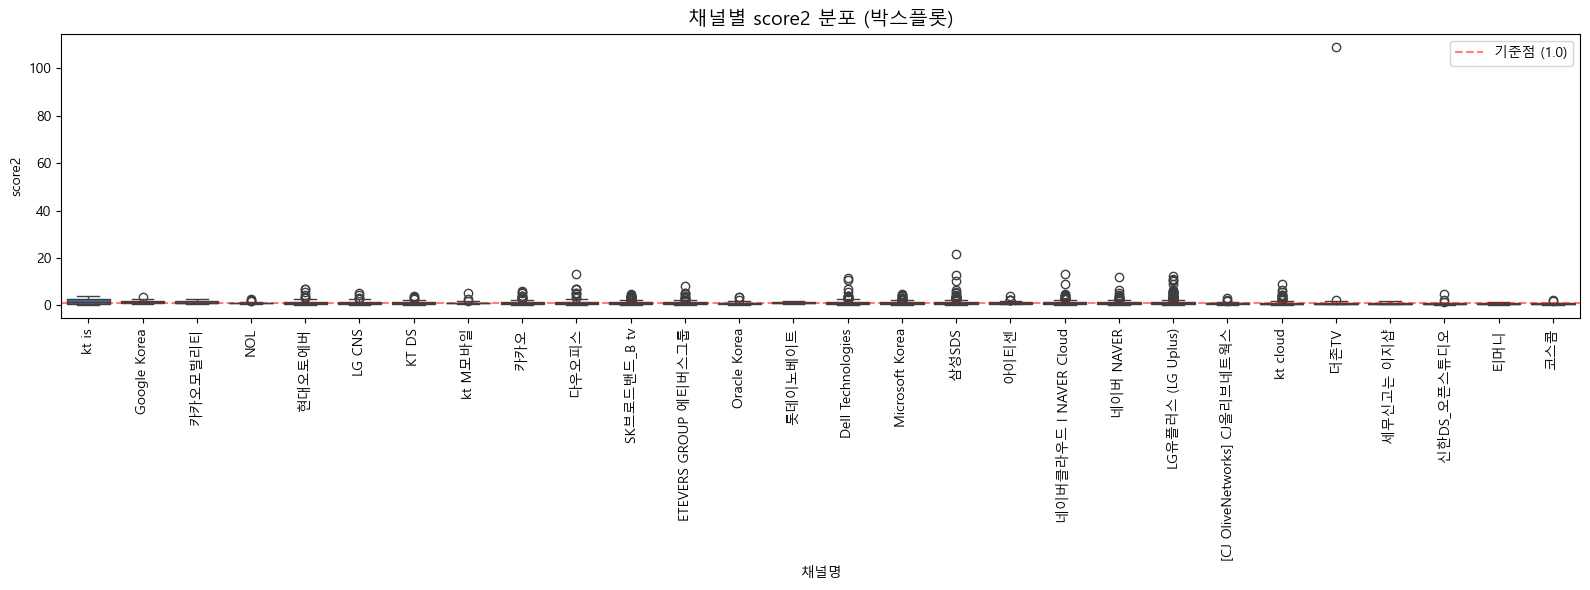

In [32]:
# Phase 4 - score2 채널별 분포 비교 시각화 (박스플롯)
fig, ax = plt.subplots(figsize=(16, 6))

# 채널별 score2 중앙값 기준으로 정렬
channel_order2 = (
    df_target_main2.groupby('채널명')['score2']
    .median()
    .sort_values(ascending=False)
    .index
)

# 박스플롯
sns.boxplot(
    data=df_target_main2,
    x='채널명', y='score2',
    order=channel_order2,
    ax=ax
)
ax.set_title('채널별 score2 분포 (박스플롯)', fontsize=14)
ax.set_xlabel('채널명')
ax.set_ylabel('score2')
ax.tick_params(axis='x', rotation=90)
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='기준점 (1.0)')
ax.legend()

plt.tight_layout()
plt.show()

#### 지표별 점수 범위(참고)

- 지표 1 (score1)
    - 범위: 0 ~ 1
    - 설계 방식: RR, ER을 전체 영상 기준 백분위로 변환 후 가중합
    - 기준점: 0.5 (전체 영상의 중앙값)
    - 해석: 1.0에 가까울수록 전체 영상 중 상위권

- 지표 2 (score2)
    - 범위: 0 ~ ∞ (이론상 상한 없음)
    - 설계 방식: 직전 3개월 참조 그룹 대비 상대 성과의 가중합
    - 기준점: 1.0 (직전 3개월 참조 그룹의 산술평균과 동일한 성과)
    - 해석: 1.0 초과 → 참조 그룹 평균보다 좋은 성과
           1.0 미만 → 참조 그룹 평균보다 나쁜 성과

---
### **6. 두 지표 중 어느 것이 메인으로 좋을까~**
**(1) 두 지표 간 상관관계**

   → 상관이 낮으면 서로 다른 측면을 측정

   → 어떤 측면이 우리 목적에 더 맞는지 판단

**(2) 채널 간 변별력**

   → 채널마다 점수 차이가 뚜렷한 지표가 더 유용

   → 시각화에서 score2는 채널 간 차이가 작아 보임

**(3) 우리 목적**

   → FnB에 속하는 서로 다른 회사 유튜브간의 숏츠 성과를 평가

   → 채널 간 비교 vs 채널 내 시계열 변화 중 무엇이 더 중요한가

[score1 vs score2 Spearman 상관계수]
상관계수: 0.3936
p-value : 3.7652e-161
샘플 수 : 4349


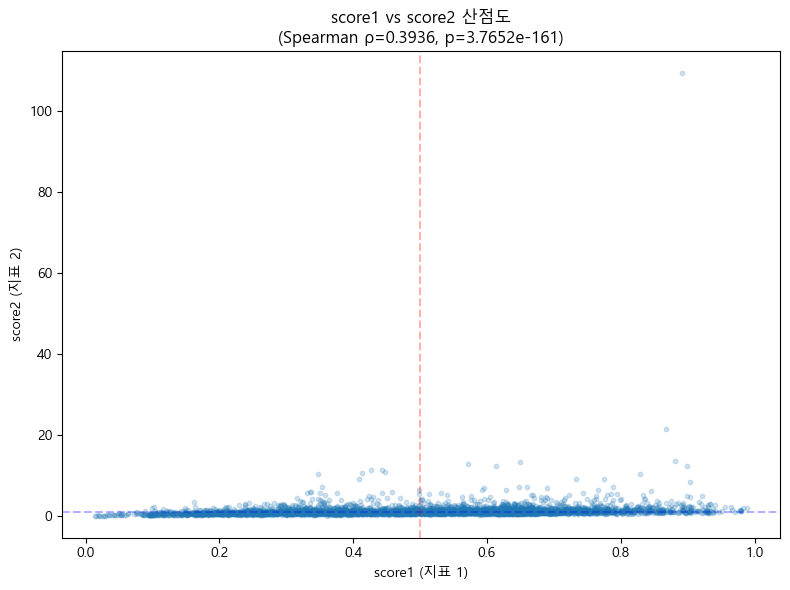

In [33]:
# Step 1. score1 vs score2 상관관계 분석

# score1과 score2가 공통으로 존재하는 영상만 사용
df_both = df_target_main2[['score1', 'score2']].dropna()

# Spearman 상관계수
corr, p_value = stats.spearmanr(df_both['score1'], df_both['score2'])

print(f"[score1 vs score2 Spearman 상관계수]")
print(f"상관계수: {corr:.4f}")
print(f"p-value : {p_value:.4e}")
print(f"샘플 수 : {len(df_both)}")

# 산점도
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df_both['score1'], df_both['score2'], alpha=0.2, s=10)
ax.set_xlabel('score1 (지표 1)')
ax.set_ylabel('score2 (지표 2)')
ax.set_title(f'score1 vs score2 산점도\n(Spearman ρ={corr:.4f}, p={p_value:.4e})')
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.3)
ax.axhline(y=1.0, color='blue', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
# Step2. 채널별 score1, score2 중앙값의 분산 비교
# → 분산이 클수록 채널 간 변별력이 높음
score1_var = df_target_main2.groupby('채널명')['score1'].median().var()
score2_var = df_target_main2.groupby('채널명')['score2'].median().var()

print(f"score1 채널별 중앙값의 분산: {score1_var:.4f}")
print(f"score2 채널별 중앙값의 분산: {score2_var:.4f}")

score1 채널별 중앙값의 분산: 0.0206
score2 채널별 중앙값의 분산: 0.0387


---
### **7. 메인 지표 선택 결과**

- **메인 지표: `score2` (지표 2)**
- 보조 지표: `score1` (지표 1)

- 선택 근거
    - 두 지표 간 상관관계
        - Spearman ρ = 0.20 (약한 상관)
        - 두 지표가 거의 독립적으로 움직임
        - `score1`: 전체 영상 풀에서의 절대적 성과 순위
        - `score2`: 해당 채널의 최근 흐름 대비 상대적 성과

    - 최종 목적에 더 적합한 지표
        - 목적: 성공한 영상의 특성을 찾아 영상 제작 및 업로드 가이드 제공
        - `score1`은 채널 규모(구독자 수)의 영향을 받아
          "잘 만든 영상"이 아닌 "큰 채널의 영상"을 성공으로 볼 위험이 있음
        - `score2`는 같은 채널 내 최근 영상 대비 성과를 측정하므로
          채널 규모와 무관하게 영상 콘텐츠 자체의 성과를 반영
        - 예시: 구독자 1만 채널에서 조회수 10만이 터진 영상은
                `score1`에서는 낮게 평가되지만
                `score2`에서는 높게 평가됨

    - 채널 간 변별력
        - `score1` 채널별 중앙값 분산: 0.0176
        - `score2` 채널별 중앙값 분산: 0.0250
        - `score2`의 분산이 더 크나, 이상치에 의한 과대평가 가능성 존재
        - `score1`은 채널 간 비교에 유리하므로 보조 지표로 활용

---
### 8. 이후 분석 아이디어

- 메인 지표 (`score2`) 기준으로 진행

- 성공/실패 영상 기준 설정 (회의 후, 이 방향으로 진행된다면)
    - `score2` 기준 상위 N% = 성공
    - `score2` 기준 하위 N% = 실패

- 성공/실패 영상 특성 분석
    - 업로드 타이밍: 요일, 시간대, 분기
    - 영상 속성: 영상 길이, 카테고리, 화질
    - 콘텐츠 속성: 제목 길이, 태그 수, 설명 길이

- 페르소나 기업별 가이드 도출
    - 분석 결과를 토대로 영상 제작 및 업로드 가이드 제공

---

### 지표1, 2의 IQR 계산 -> 교집합 확인

In [35]:
# -------------------------------------------------------
# 두 지표 모두 상위 25%, 하위 25%에 속하는 영상 확인
# -------------------------------------------------------

# score1 상위/하위 25% 기준
q75_s1 = df_target_main2['score1'].quantile(0.75)
q25_s1 = df_target_main2['score1'].quantile(0.25)

# score2 상위/하위 25% 기준
q75_s2 = df_target_main2['score2'].quantile(0.75)
q25_s2 = df_target_main2['score2'].quantile(0.25)

# 두 지표 모두 상위 25%
both_top = df_target_main2[
    (df_target_main2['score1'] >= q75_s1) &
    (df_target_main2['score2'] >= q75_s2)
]

# 두 지표 모두 하위 25%
both_bottom = df_target_main2[
    (df_target_main2['score1'] <= q25_s1) &
    (df_target_main2['score2'] <= q25_s2)
]

print(f"[두 지표 모두 상위 25%]")
print(f"영상 수: {len(both_top)}개 ({len(both_top)/len(df_target_main2)*100:.1f}%)")

print(f"\n[두 지표 모두 하위 25%]")
print(f"영상 수: {len(both_bottom)}개 ({len(both_bottom)/len(df_target_main2)*100:.1f}%)")

[두 지표 모두 상위 25%]
영상 수: 412개 (9.5%)

[두 지표 모두 하위 25%]
영상 수: 526개 (12.1%)


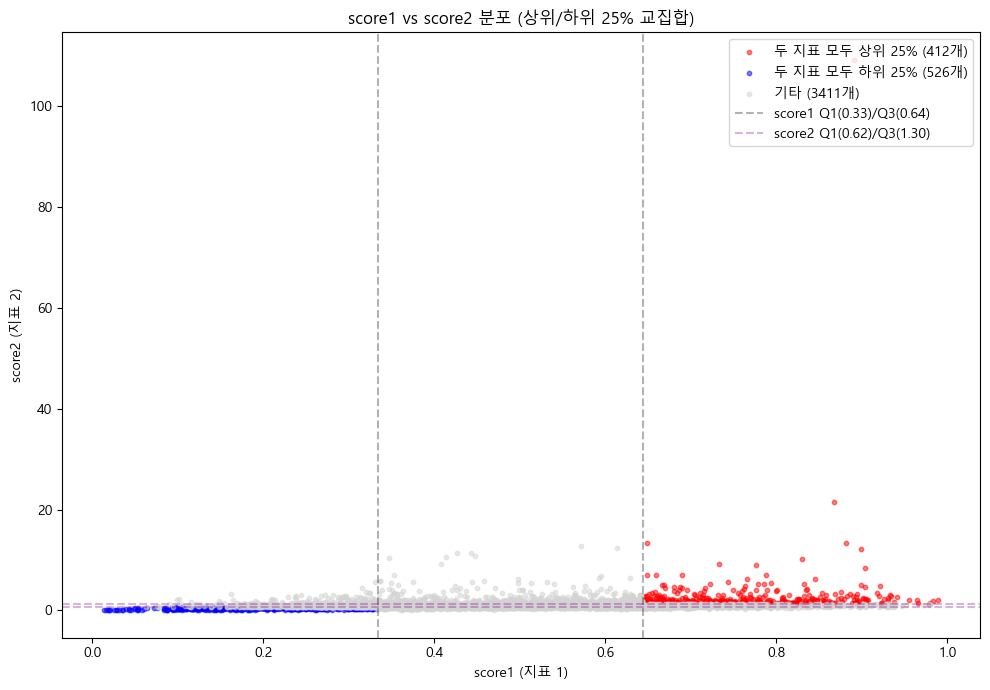

In [36]:
# -------------------------------------------------------
# 두 지표 상위/하위 25% 교집합 시각화
# -------------------------------------------------------

# 그룹 분류
conditions = [
    (df_target_main2['score1'] >= q75_s1) & (df_target_main2['score2'] >= q75_s2),
    (df_target_main2['score1'] <= q25_s1) & (df_target_main2['score2'] <= q25_s2),
]
choices = ['두 지표 모두 상위 25%', '두 지표 모두 하위 25%']
df_target_main2['group'] = np.select(conditions, choices, default='기타')

# 색상 설정
color_map = {
    '두 지표 모두 상위 25%': 'red',
    '두 지표 모두 하위 25%': 'blue',
    '기타': 'lightgray'
}

fig, ax = plt.subplots(figsize=(10, 7))

for group, color in color_map.items():
    subset = df_target_main2[df_target_main2['group'] == group]
    ax.scatter(
        subset['score1'], subset['score2'],
        c=color, label=f"{group} ({len(subset)}개)",
        alpha=0.5, s=10
    )

# 기준선
ax.axvline(x=q25_s1, color='black', linestyle='--', alpha=0.3, label=f'score1 Q1({q25_s1:.2f})/Q3({q75_s1:.2f})')
ax.axvline(x=q75_s1, color='black', linestyle='--', alpha=0.3)
ax.axhline(y=q25_s2, color='purple', linestyle='--', alpha=0.3, label=f'score2 Q1({q25_s2:.2f})/Q3({q75_s2:.2f})')
ax.axhline(y=q75_s2, color='purple', linestyle='--', alpha=0.3)

ax.set_xlabel('score1 (지표 1)')
ax.set_ylabel('score2 (지표 2)')
ax.set_title('score1 vs score2 분포 (상위/하위 25% 교집합)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

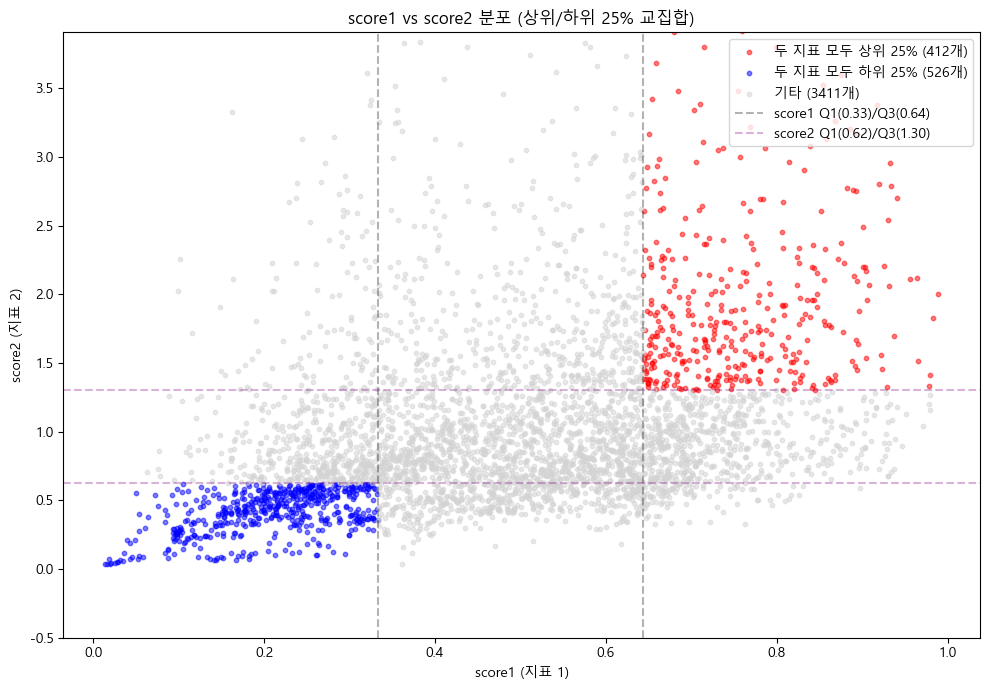

In [37]:
# -------------------------------------------------------
# 두 지표 상위/하위 25% 교집합 시각화
# -------------------------------------------------------

# 그룹 분류
conditions = [
    (df_target_main2['score1'] >= q75_s1) & (df_target_main2['score2'] >= q75_s2),
    (df_target_main2['score1'] <= q25_s1) & (df_target_main2['score2'] <= q25_s2),
]
choices = ['두 지표 모두 상위 25%', '두 지표 모두 하위 25%']
df_target_main2['group'] = np.select(conditions, choices, default='기타')

# 색상 설정
color_map = {
    '두 지표 모두 상위 25%': 'red',
    '두 지표 모두 하위 25%': 'blue',
    '기타': 'lightgray'
}

fig, ax = plt.subplots(figsize=(10, 7))

for group, color in color_map.items():
    subset = df_target_main2[df_target_main2['group'] == group]
    ax.scatter(
        subset['score1'], subset['score2'],
        c=color, label=f"{group} ({len(subset)}개)",
        alpha=0.5, s=10
    )

# 기준선
ax.axvline(x=q25_s1, color='black', linestyle='--', alpha=0.3, label=f'score1 Q1({q25_s1:.2f})/Q3({q75_s1:.2f})')
ax.axvline(x=q75_s1, color='black', linestyle='--', alpha=0.3)
ax.axhline(y=q25_s2, color='purple', linestyle='--', alpha=0.3, label=f'score2 Q1({q25_s2:.2f})/Q3({q75_s2:.2f})')
ax.axhline(y=q75_s2, color='purple', linestyle='--', alpha=0.3)

ax.set_xlabel('score1 (지표 1)')
ax.set_ylabel('score2 (지표 2)')
ax.set_ylim(-0.5, q75_s2 * 3) # y축 범위 제한 (score2 IQR 기준)
ax.set_title('score1 vs score2 분포 (상위/하위 25% 교집합)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [38]:
def calc_score2(row, a, b, c):
    
    view = row['조회수성과']
    like = row['좋아요성과']
    comm = row['댓글성과']
    
    # 조회수성과가 없는 경우
    # → 참조 그룹의 평균 일평균 조회수가 0인 경우로 데이터 오류 가능성이 높아 제외
    if pd.isna(view):
        return None
    
    # 세 지표 모두 있는 경우
    if pd.notna(like) and pd.notna(comm):
        return a*view + b*like + c*comm
    
    # 좋아요성과만 없는 경우 → a, c 재조정
    elif pd.isna(like) and pd.notna(comm):
        a_new = a / (a + c)
        c_new = c / (a + c)
        return a_new*view + c_new*comm
    
    # 댓글성과만 없는 경우 → a, b 재조정
    elif pd.notna(like) and pd.isna(comm):
        a_new = a / (a + b)
        b_new = b / (a + b)
        return a_new*view + b_new*like
    
    # 좋아요성과, 댓글성과 모두 없는 경우
    # → 조회수성과만으로는 신뢰도가 낮으므로 제외
    else:
        return None

df_target_main['score2'] = df_target_main.apply(
    lambda row: calc_score2(row, a_pca, b_pca, c_pca), axis=1
)

# 확인
print(f"[score2 결측값 현황]")
print(f"전체 영상 수: {len(df_target_main)}")
print(f"score2 계산 가능: {df_target_main['score2'].notna().sum()}개")
print(f"score2 결측값: {df_target_main['score2'].isna().sum()}개")
print(f"\n[score2 통계]")
print(df_target_main['score2'].describe())

[score2 결측값 현황]
전체 영상 수: 4621
score2 계산 가능: 4528개
score2 결측값: 93개

[score2 통계]
count    4528.000000
mean        1.154521
std         1.909227
min         0.034678
25%         0.627892
50%         0.882334
75%         1.308346
max       109.249057
Name: score2, dtype: float64
